# 3.2 Airbnb Price Prediction — Predictive Analysis Pipeline
**Jackson School of Global Affairs**  
Ardina Hasanbasri (GLBL 5021)  
Reference: Békés & Kézdi (2021) https://gabors-data-analysis.com/

---
**Stages:**
1. Create holdout and working samples
2. Build and Estimate 8 OLS candidate models via 4-fold CV
3. Select the best model by CV RMSE, R-squared, and BIC
4. Evaluate the final model on the holdout sample

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

# Since you learned how to make functions, here are some helper functions.
def mse_lev(pred, y):
    return np.mean((pred - y) ** 2)

def rmse_lev(pred, y):
    return mse_lev(pred, y) ** 0.5

## 0. Load data

In [33]:
data = pd.read_csv('airbnb_hackney_workfile_adj_book1.csv')

# Convert numeric columns that may have been read as strings
numeric_cols = [
    'usd_cleaning_fee', 'usd_price_day', 'p_host_response_rate',
    'n_accommodates', 'n_bathrooms', 'n_review_scores_rating',
    'n_number_of_reviews', 'n_guests_included', 'n_reviews_per_month',
    'n_extra_people', 'n_minimum_nights', 'n_beds', 'n_days_since', 'price',
    'n_accommodates2', 'n_days_since2', 'n_days_since3',
    'f_bathroom', 'f_number_of_reviews', 'f_minimum_nights'
]
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Some additional cleaning: impute missing values with median and create flags
for var in ['n_days_since', 'n_review_scores_rating', 'n_reviews_per_month']:
    flag_name = var.replace('n_', 'flag_')
    data[flag_name] = data[var].isna().astype(int)
    data[var] = data[var].fillna(data[var].median())

data.head()

,usd_cleaning_fee,f_property_type,f_room_type,f_room_type2,f_cancellation_policy,f_bed_type,f_neighbourhood_cleansed,usd_price_day,p_host_response_rate,n_accommodates,...,ln_days_since,ln_days_since2,ln_days_since3,n_days_since2,n_days_since3,ln_review_scores_rating,f_minimum_nights,flag_days_since,flag_review_scores_rating,flag_reviews_per_month
0,NaN,Apartment,Private room,Private,flexible,Real Bed,Hackney,65,100.0,2,...,7.290975,53.158313,387.575921,2152089.0,3.157115e+09,4.521789,1.0,0,0,0
1,NaN,House,Private room,Private,moderate,Real Bed,Hackney,30,NaN,2,...,6.350886,40.333749,256.155033,328329.0,1.881325e+08,4.499810,1.0,0,0,0
2,NaN,Apartment,Private room,Private,moderate,Couch,Hackney,150,100.0,7,...,7.461066,55.667499,415.338854,3024121.0,5.258946e+09,4.574711,2.0,0,0,0
3,25.0,House,Private room,Private,moderate,Real Bed,Hackney,29,100.0,2,...,6.385194,40.770708,260.328893,351649.0,2.085279e+08,4.543295,1.0,0,0,0
4,20.0,Apartment,Entire home/apt,Entire/Apt,moderate,Real Bed,Hackney,65,100.0,2,...,7.288244,53.118506,387.140657,2140369.0,3.131360e+09,4.477337,2.0,0,0,0


## 1. List all models we will build in this exercise

Model choices are decided through domain knowledge and exploratory data analysis.

In Python we define models as lists of column names.  
Categorical variables are one-hot encoded and interaction terms are created manually as new columns.

### Part I: Model Building and Estimation

1) Why should we do cross-validation when estimating the model?

- We care about cross-validation so that we can average the RMSEs across model and then compare them properly. It allows us to get a more precise understanding of the RMSEs for the specific models across the folds.

2) What sample is used to calculate the Test RMSE?

- We calculate the test RMSE for a specific fold from the working data. Then we average the test RMSEs across the folds.

3) What sample is used to calculate the BIC?

- The full non-folded working data to see the penalties for overfitting.

4) The OLS model does not calculate robust standard errors. Do you see this as a problem?

- This is not a big issue, as we don't look at specific coefficients and their significance (we would care about the problem of a possibly heteroskedastic data). Right now, we only care about minimizing model errors.

In [34]:
# --- One-hot encode categorical variables ------------------------------------
# drop_first=True drops the base category to avoid perfect multicollinearity
# base categories: Apartment, Entire home/apt, Couch, flexible, 0 bathrooms, 0 reviews

cat_vars = ['f_property_type', 'f_room_type', 'f_bed_type',
            'f_cancellation_policy', 'f_bathroom', 'f_number_of_reviews']

data = pd.get_dummies(data, columns=cat_vars, drop_first=True, dtype=float)

# Rename dummies to clean short names for readability
rename_map = {
    # property type
    'f_property_type_House':              'prop_house',
    # room type
    'f_room_type_Private room':           'room_private',
    'f_room_type_Shared room':            'room_shared',
    # bed type
    'f_bed_type_Real Bed':                'bed_realbed',
    # cancellation policy
    'f_cancellation_policy_moderate':     'cancel_moderate',
    'f_cancellation_policy_strict':       'cancel_strict',
    # bathroom (f_bathroom is numeric 0/1/2 so get_dummies gives _1.0 and _2.0)
    'f_bathroom_1.0':                     'bath_1',
    'f_bathroom_2.0':                     'bath_2',
    # number of reviews (same pattern)
    'f_number_of_reviews_1.0':            'nrev_1',
    'f_number_of_reviews_2.0':            'nrev_2',
}
data = data.rename(columns=rename_map)

# --- Amenity columns ---------------------------------------------------------
amenities = [c for c in data.columns if c.startswith('d_')]

# --- Create interaction terms as explicit columns ----------------------------

# X1: f_room_type * f_property_type
data['room_private_x_house']   = data['room_private'] * data['prop_house']
data['room_shared_x_house']    = data['room_shared']  * data['prop_house']

# X1: f_room_type * d_familykidfriendly
data['room_private_x_family']  = data['room_private'] * data['d_familykidfriendly']
data['room_shared_x_family']   = data['room_shared']  * data['d_familykidfriendly']

# X2: d_airconditioning, d_cats, d_dogs each x f_property_type
data['aircond_x_house']        = data['d_airconditioning'] * data['prop_house']
data['cats_x_house']           = data['d_cats']            * data['prop_house']
data['dogs_x_house']           = data['d_dogs']            * data['prop_house']

# X3: (f_property_type + f_room_type + f_cancellation_policy + f_bed_type) x all amenities
cat_dummies_for_x3 = ['prop_house', 'room_private', 'room_shared',
                       'cancel_moderate', 'cancel_strict', 'bed_realbed']

x3_cols = []
for amen in amenities:
    for cat in cat_dummies_for_x3:
        col_name = f'{amen}_x_{cat}'
        data[col_name] = data[amen] * data[cat]
        x3_cols.append(col_name)

# --- Define predictor groups (mirrors R code) --------------------------------
basic_lev = ['n_accommodates', 'n_beds', 'prop_house', 'room_private', 'room_shared',
             'n_days_since', 'flag_days_since']

basic_add = ['bath_1', 'bath_2', 'cancel_moderate', 'cancel_strict', 'bed_realbed']

reviews   = ['nrev_1', 'nrev_2', 'n_review_scores_rating', 'flag_review_scores_rating']

poly_lev  = ['n_accommodates2', 'n_days_since2', 'n_days_since3']

X1 = ['room_private_x_house', 'room_shared_x_house',
      'room_private_x_family', 'room_shared_x_family']

X2 = ['aircond_x_house', 'cats_x_house', 'dogs_x_house']

# --- Model formulas (lists of column names) ----------------------------------
model1 = ['n_accommodates']
model2 = basic_lev
model3 = basic_lev + basic_add + reviews
model4 = basic_lev + basic_add + reviews + poly_lev
model5 = basic_lev + basic_add + reviews + poly_lev + X1
model6 = basic_lev + basic_add + reviews + poly_lev + X1 + X2
model7 = basic_lev + basic_add + reviews + poly_lev + X1 + X2 + amenities
model8 = basic_lev + basic_add + reviews + poly_lev + X1 + X2 + amenities + x3_cols

model_formulas = {
    'model1': model1,
    'model2': model2,
    'model3': model3,
    'model4': model4,
    'model5': model5,
    'model6': model6,
    'model7': model7,
    'model8': model8,
}

print(f'Number of predictors per model:')
for name, cols in model_formulas.items():
    print(f'  {name}: {len(cols)}')

Number of predictors per model:
  model1: 1
  model2: 7
  model3: 16
  model4: 19
  model5: 23
  model6: 26
  model7: 76
  model8: 376


## 2. Split into holdout (20%) and working (80%) samples

Drop NAs only in columns used by model5 (the most complex model).  
This ensures all models are trained on the same observations so BIC and RMSE are directly comparable.  
This is also required because sklearn cannot handle missing data.

In [35]:
# Drop NAs only in columns used by model8
all_vars = list(set(["price"] + model1 + model2 + model3 + model4 + model5 + model6 + model7 + model8))

data_clean = data[all_vars].dropna()

data_work, data_holdout = train_test_split(
    data_clean, test_size=0.2, random_state=20180123
)

# 80/20 split — random_state replicates set.seed() in R
data_work, data_holdout = train_test_split(
    data_clean, test_size=0.2, random_state=20180123
)

print(f"Working sample size  : {len(data_work)}")
print(f"Holdout  sample size : {len(data_holdout)}")

print("Columns after rename:")
print(data.columns.tolist())

print("\nColumns in data_work:")
print(data_work.columns.tolist())

Working sample size  : 2512
Holdout  sample size : 629
Columns after rename:
['usd_cleaning_fee', 'f_room_type2', 'f_neighbourhood_cleansed', 'usd_price_day', 'p_host_response_rate', 'n_accommodates', 'n_bathrooms', 'n_review_scores_rating', 'n_number_of_reviews', 'n_guests_included', 'n_reviews_per_month', 'n_extra_people', 'n_minimum_nights', 'n_beds', 'n_days_since', 'd_24hourcheckin', 'd_airconditioning', 'd_breakfast', 'd_buzzerwirelessintercom', 'd_cabletv', 'd_carbonmonoxidedetector', 'd_cats', 'd_dogs', 'd_doorman', 'd_doormanentry', 'd_dryer', 'd_elevatorinbuilding', 'd_essentials', 'd_familykidfriendly', 'd_fireextinguisher', 'd_firstaidkit', 'd_freeparkingonpremises', 'd_freeparkingonstreet', 'd_gym', 'd_hairdryer', 'd_hangers', 'd_heating', 'd_hottub', 'd_indoorfireplace', 'd_internet', 'd_iron', 'd_keypad', 'd_kitchen', 'd_laptopfriendlyworkspace', 'd_lockonbedroomdoor', 'd_lockbox', 'd_otherpets', 'd_paidparkingoffpremises', 'd_petsallowed', 'd_petsliveonthisproperty', 'd

## 3. Estimate models using 4-fold CV

We fit each model on the full working sample (for BIC and R-squared),  
then run 4-fold cross-validation to get out-of-sample RMSE estimates.

In [36]:
# --- 4-fold CV folds (created once, reused for all models) -------------------
n_folds = 4
kf = KFold(n_splits=n_folds, shuffle=True, random_state=20180124)

# --- CV loop -----------------------------------------------------------------
model_results_cv = {}

for model_name, features in model_formulas.items():

    X_work = data_work[features].values
    y_work = data_work["price"].values

    rmse_train_folds = np.zeros(n_folds)  # Creates empty arrays with length depending on the folds.
    rmse_test_folds  = np.zeros(n_folds)

    # Fit on full working data for BIC / R-squared
    model_full = LinearRegression()
    model_full.fit(X_work, y_work)

    pred_full = model_full.predict(X_work)
    n         = len(y_work)
    k       = X_work.shape[1] + 1        # predictors + intercept, no sigma squared. This is for simplified formula of BIC to ease comparison across packages and softwares.
    rss = np.sum(np.power(pred_full-y_work,2))
    log_lik = -n / 2 * np.log(rss / n)
    BIC_val = -2 * log_lik + np.log(n) * k
    r2        = r2_score(y_work, pred_full)
    nvars     = X_work.shape[1]

    # k-fold estimation to get RMSE
    for k_idx, (train_idx, test_idx) in enumerate(kf.split(X_work)):
        X_train, X_test = X_work[train_idx], X_work[test_idx]
        y_train, y_test = y_work[train_idx], y_work[test_idx]

        model_k = LinearRegression()
        model_k.fit(X_train, y_train)

        pred_train = model_k.predict(X_train)  # training portion of this fold
        pred_test  = model_k.predict(X_test)   # validation portion of this fold

        rmse_train_folds[k_idx] = rmse_lev(pred_train, y_train)
        rmse_test_folds[k_idx]  = rmse_lev(pred_test,  y_test)

    # Saving all the results into a dictionary.
    model_results_cv[model_name] = {
        "features":        features,
        "model_work_data": model_full,
        "rmse_train":      rmse_train_folds,
        "rmse_test":       rmse_test_folds,
        "BIC":             BIC_val,
        "nvars":           nvars,
        "r2":              r2,
    }

print("CV complete for all OLS models.")

CV complete for all OLS models.


### Part II: LASSO

1) What is the role of lambda in the LASSO code?

- The lambda parameter defines the severity of punishment of overfitting (including too many variables). The larger the lambda, the stronger the punishment.

2) If the lambda is larger, would you get more variables selected or less? Explain (Students might be able to run the code to restrict the lambda to see).

- As the lambda parameter belongs to the "punishment" term that is added to the OLS equation, a larger lambda will lead to more coefficient being reduced to zero. Therefore, less variables selected in the end.

3) Would you be able to calculate RMSE for the LASSO model? Would it be comparable to the OLS results? Explain

- Yes, you can. No it would not be comparable to the OLS result, as the LASSO and OLS are different. The LASSO is conducted on the whole working set, whilst the OLS RMSE is done on the k-fold sets.

In [37]:
X_lasso        = data_work[model8].values
y_lasso        = data_work["price"].values
scaler         = StandardScaler()
X_lasso_scaled = scaler.fit_transform(X_lasso)

lasso_cv = LassoCV(
#    alphas=np.arange(0.05, 1.05, 0.05),   # equivalent to seq(0.05, 1, by=0.05) in R
    cv=n_folds,
    random_state=1234,
#    max_iter=10000
)
lasso_cv.fit(X_lasso_scaled, y_lasso)

best_lambda   = lasso_cv.alpha_
lasso_fitted  = lasso_cv.predict(X_lasso_scaled)
# If you want to calculate rmse. 
lasso_cv_rmse = rmse_lev(lasso_fitted, y_lasso)

# If you want to get BIC for LASSO
# (RSS-based, equivalent to likelihood under normality)
n_lasso   = len(y_lasso)
rss_lasso = np.sum((y_lasso - lasso_fitted) ** 2)
df_lasso  = np.sum(lasso_cv.coef_ != 0)    # non-zero coefficients (excl. intercept)
lasso_bic = n_lasso * np.log(rss_lasso / n_lasso) + np.log(n_lasso) * df_lasso

print(f"Best LASSO lambda : {best_lambda:.4f}")
print(f"LASSO BIC         : {lasso_bic:.3f}")

Best LASSO lambda : 0.9828
LASSO BIC         : 18335.829


In [38]:
X_lasso        = data_work[model8].values
y_lasso        = data_work["price"].values
scaler         = StandardScaler()
X_lasso_scaled = scaler.fit_transform(X_lasso)

lasso_cv = LassoCV(
#    alphas=np.arange(0.05, 1.05, 0.05),   # equivalent to seq(0.05, 1, by=0.05) in R
    cv=n_folds,
    random_state=1234,
#    max_iter=10000
)
lasso_cv.fit(X_lasso_scaled, y_lasso)

best_lambda   = lasso_cv.alpha_
lasso_fitted  = lasso_cv.predict(X_lasso_scaled)
# If you want to calculate rmse. 
lasso_cv_rmse = rmse_lev(lasso_fitted, y_lasso)

# If you want to get BIC for LASSO
# (RSS-based, equivalent to likelihood under normality)
n_lasso   = len(y_lasso)
rss_lasso = np.sum((y_lasso - lasso_fitted) ** 2)
df_lasso  = np.sum(lasso_cv.coef_ != 0)    # non-zero coefficients (excl. intercept)
lasso_bic = n_lasso * np.log(rss_lasso / n_lasso) + np.log(n_lasso) * df_lasso

print(f"Best LASSO lambda : {best_lambda:.4f}")
print(f"LASSO BIC         : {lasso_bic:.3f}")

Best LASSO lambda : 0.9828
LASSO BIC         : 18335.829


## 4. Select the best model — compare CV RMSE, R-squared, and BIC

### Part III: Selecting the Best Model

1) Copy the results here of the model side-by-side comparison. According to each metric, which one is the best model?

- [results are shown below]
- Best models per:
  - R-squared: Model 8
  - BIC: Model 4
  - Training/Test RMSE: Model 7

2) Which one do you think will be a good model? Explain.

- I think the best model will be model 7, as the CV test RMSE is the more deeper (although more computationally demanding) metric than the BIC. 

In [39]:
rows = []
for model_name, res in model_results_cv.items():
    rows.append({
        "Model":          model_name,
        "N predictors":   res["nvars"],
        "R-squared":      round(res["r2"], 3),
        "BIC":            round(res["BIC"], 1),
        "Training RMSE":  round(res["rmse_train"].mean(), 3),
        "Test RMSE":      round(res["rmse_test"].mean(), 3),
    })

fit_summary = pd.DataFrame(rows)

# --- Add LASSO row for side-by-side comparison -------------------------------
lasso_row = pd.DataFrame([{
    "Model":          "LASSO",
    "N predictors":   int(np.sum(lasso_cv.coef_ != 0)),
    "R-squared":      None,
    "BIC":            round(lasso_bic, 1),
    "Training RMSE":  None,
    "Test RMSE":      None
}])

fit_summary = pd.concat([fit_summary, lasso_row], ignore_index=True)

print("=== Full Model Comparison including LASSO ===")
fit_summary

=== Full Model Comparison including LASSO ===


C:\Users\nepoz\AppData\Local\Temp\ipykernel_24664\2990623296.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fit_summary = pd.concat([fit_summary, lasso_row], ignore_index=True)


,Model,N predictors,R-squared,BIC,Training RMSE,Test RMSE
0,model1,1,0.485,18657.9,40.857,40.761
1,model2,7,0.546,18390.5,38.358,38.358
2,model3,16,0.567,18341.6,37.425,37.587
3,model4,19,0.583,18271.2,36.731,36.955
4,model5,23,0.583,18297.9,36.690,36.973
5,model6,26,0.585,18313.2,36.626,36.944
6,model7,76,0.611,18539.5,35.339,36.435
7,model8,376,0.652,20612.2,32.928,42.355
8,LASSO,51,NaN,18335.8,NaN,NaN


In [40]:
# --- Identify winners --------------------------------------------------------
best_model     = fit_summary.loc[fit_summary["Test RMSE"].idxmin(), "Model"]
best_bic_model = fit_summary.dropna(subset=["BIC"]).loc[
                     fit_summary.dropna(subset=["BIC"])["BIC"].idxmin(), "Model"
                 ]

print(f"Best model by CV test RMSE : {best_model}")
print(f"Best model by BIC          : {best_bic_model}")

# Point to the winning model object.
# LASSO needs special handling at prediction time (scaled matrix input).
if best_model == "LASSO":
    final_model  = lasso_cv
    final_scaler = scaler
else:
    final_model  = model_results_cv[best_model]["model_work_data"]
    final_scaler = None

Best model by CV test RMSE : model7
Best model by BIC          : model4


## 5. Evaluate the final model on the holdout sample

The holdout data is used for the **first — and only — time** here.

### Part IV: The Holdout Sample

1) If the price is in dollars (it’s not since this is Hackney), explain how you would interpret the RMSE? What about the AEM (see code)? How are the two different?

- The root mean-square error is ~USD30 (the root mean distance from the predicted values to the observed values). The MAE (mean absolute error) is ~USD20. The RMSE penalizes outliers more than the MAE, which is why it's larger.

2) From the graph, provide some insights that could help you decide whether this would be a good model, how to use the model, or how to improve the model. (Think about what happens when the points don’t align the way you expect it.)

- The model seems to work well at lower prices, where the model and holdout values seem to cluster around the 45° line. At higher prices, the model seems to undervalue the properties. Log-transforming price could possibly help the issue.

In [41]:
holdout_actuals = data_holdout["price"].values

if best_model == "LASSO":
    X_holdout_scaled = final_scaler.transform(data_holdout[model8].values)
    holdout_preds    = final_model.predict(X_holdout_scaled)
else:
    features      = model_results_cv[best_model]["features"]
    X_holdout     = data_holdout[features].values
    holdout_preds = final_model.predict(X_holdout)

holdout_rmse = rmse_lev(holdout_preds, holdout_actuals)
holdout_mae  = np.mean(np.abs(holdout_preds - holdout_actuals))
holdout_r2   = r2_score(holdout_actuals, holdout_preds)

print(f"=== Holdout Performance ( {best_model} ) ===")
print(f"  RMSE : {holdout_rmse:.3f}")
print(f"  MAE  : {holdout_mae:.3f}")
print(f"  R2   : {holdout_r2:.3f}")

=== Holdout Performance ( model7 ) ===
  RMSE : 30.176
  MAE  : 20.280
  R2   : 0.713


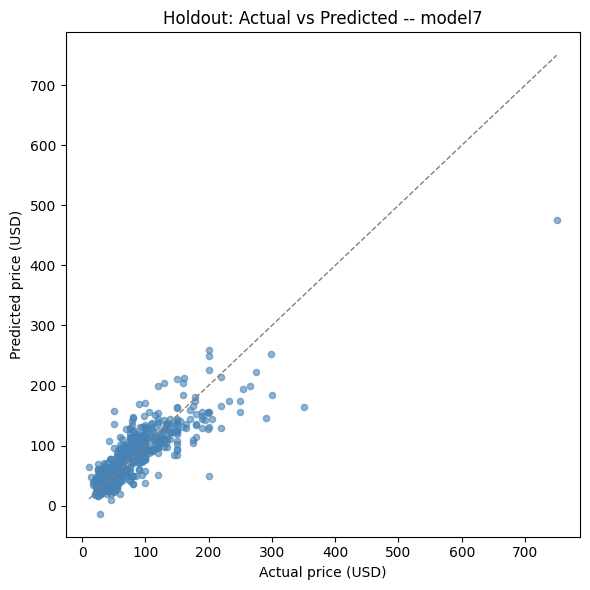

In [42]:
# --- Plot predicted vs actual on the holdout ---------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(holdout_actuals, holdout_preds,
            color="steelblue", alpha=0.6, s=20)
plt.plot([holdout_actuals.min(), holdout_actuals.max()],
         [holdout_actuals.min(), holdout_actuals.max()],
         linestyle="--", color="gray", linewidth=1)   # perfect-prediction line
plt.xlabel("Actual price (USD)")
plt.ylabel("Predicted price (USD)")
plt.title(f"Holdout: Actual vs Predicted -- {best_model}")
plt.tight_layout()
plt.show()